In [ ]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text, DecisionTreeRegressor
import numpy as np
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, r2_score, mean_squared_error

In [ ]:
RANDOM_SEED = 0

Text(0, 0.5, 'X2')

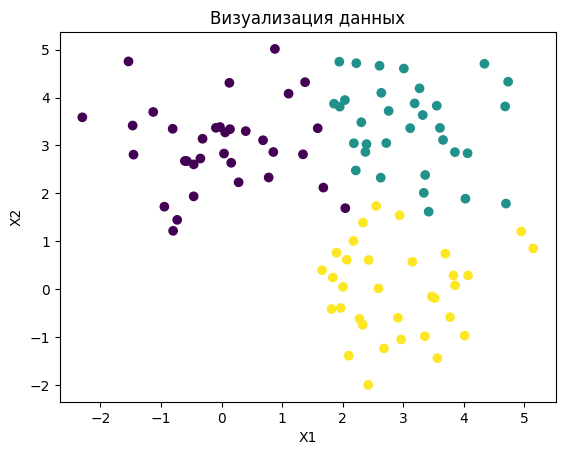

In [ ]:
X, y = make_blobs(n_samples=100, centers=[(0,3),(3,3),(3,0)],
                                      n_features=2, random_state=RANDOM_SEED,
                                      cluster_std=(0.9,0.9,0.9))
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title('Визуализация данных')
plt.xlabel('X1')
plt.ylabel('X2')

In [ ]:
depth=4
clf_tree = DecisionTreeClassifier(criterion='entropy', max_depth=depth,
                                  random_state=RANDOM_SEED)
clf_tree.fit(X, y)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=0)

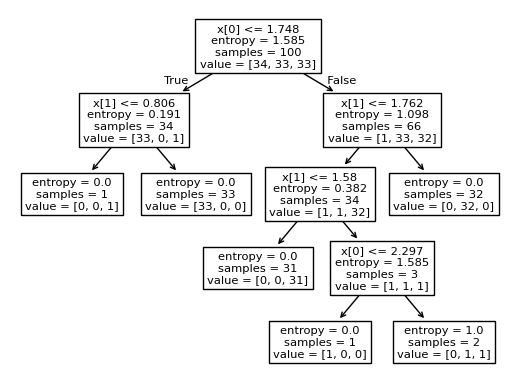

In [ ]:
plot_tree(clf_tree)
plt.show()

In [ ]:
export_text(clf_tree)

'|--- feature_0 <= 1.75\n|   |--- feature_1 <= 0.81\n|   |   |--- class: 2\n|   |--- feature_1 >  0.81\n|   |   |--- class: 0\n|--- feature_0 >  1.75\n|   |--- feature_1 <= 1.76\n|   |   |--- feature_1 <= 1.58\n|   |   |   |--- class: 2\n|   |   |--- feature_1 >  1.58\n|   |   |   |--- feature_0 <= 2.30\n|   |   |   |   |--- class: 0\n|   |   |   |--- feature_0 >  2.30\n|   |   |   |   |--- class: 1\n|   |--- feature_1 >  1.76\n|   |   |--- class: 1\n'

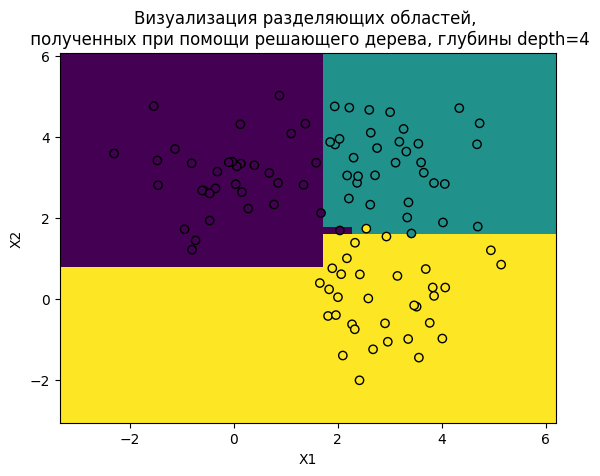

In [ ]:
X0 = np.linspace(X[:, 0].min()-1,X[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X[:, 1].min()-1,X[:, 1].max()+1, X.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf_tree.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)

plt.title('Визуализация разделяющих областей, \n полученных при помощи решающего дерева, глубины depth={}'.format(depth))
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

In [ ]:
y_pred = clf_tree.predict(X)
print(confusion_matrix(y, y_pred))
print('Accuracy =', accuracy_score(y, y_pred))
print('F1_score =', f1_score(y, y_pred, average='micro'))

[[34  0  0]
 [ 0 33  0]
 [ 0  1 32]]
Accuracy = 0.99
F1_score = 0.99


In [ ]:
observation_new = [[2, 1]]

In [ ]:
clf_tree.predict(observation_new)

array([2])

In [ ]:
n_samples = 100
X = np.sort(np.random.rand(n_samples))
y = np.exp(X ** 2)+np.random.normal(0.0, 0.1, X.shape[0])

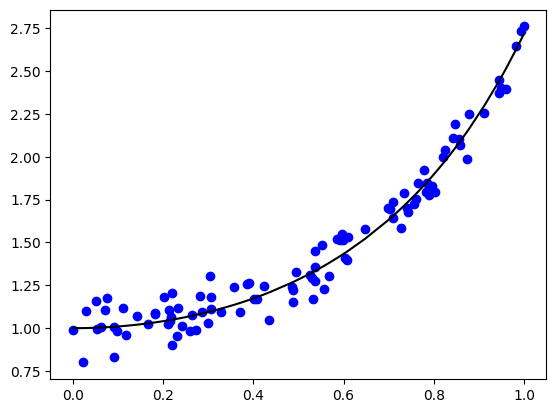

In [ ]:
plt.scatter(X, y, c="b")
plt.plot(X, np.exp(X ** 2), c = 'k')

In [ ]:
depth=2
reg_tree = DecisionTreeRegressor(max_depth=depth, random_state=RANDOM_SEED)
reg_tree.fit(X.reshape(-1, 1), y)

DecisionTreeRegressor(max_depth=2, random_state=0)

In [ ]:
y_pred_reg = reg_tree.predict(X.reshape(-1, 1))

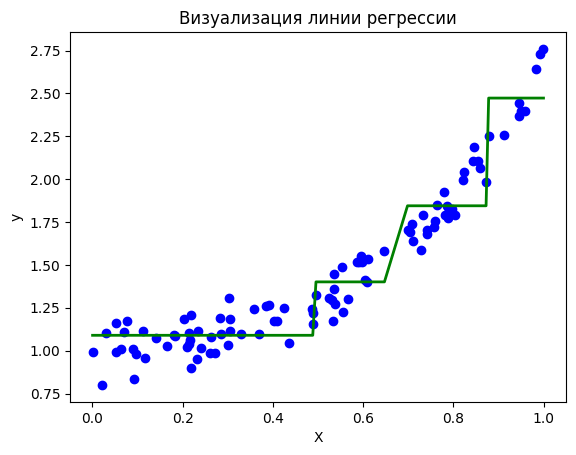

In [ ]:
plt.scatter(X, y, c="b")

plt.plot(X, y_pred_reg, "g", lw=2)

plt.title('Визуализация линии регрессии')
plt.xlabel('X')
plt.ylabel('y');

In [ ]:
print('r2= ', r2_score(y, y_pred_reg))
print('MSE= ', mean_squared_error(y, y_pred_reg))

r2=  0.9341920380030301
MSE=  0.015710665976554884


In [ ]:
observation_new = [[0.7]]

In [ ]:
reg_tree.predict(observation_new)

array([1.40629789])

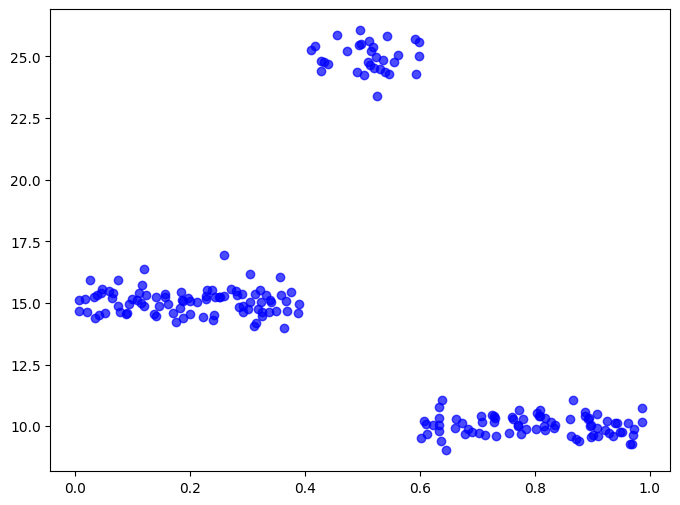

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

np.random.seed(42)
X = np.sort(np.random.rand(200, 1), axis=0)
y = np.piecewise(X.flatten(),
                 [X.flatten() < 0.4, (X.flatten() >= 0.4) & (X.flatten() < 0.6), X.flatten() >= 0.6],
                 [lambda x: 15 + np.random.normal(0, 0.5, len(x)),
                  lambda x: 25 + np.random.normal(0, 0.5, len(x)),
                  lambda x: 10 + np.random.normal(0, 0.5, len(x))])

plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', alpha=0.7, label='Data')


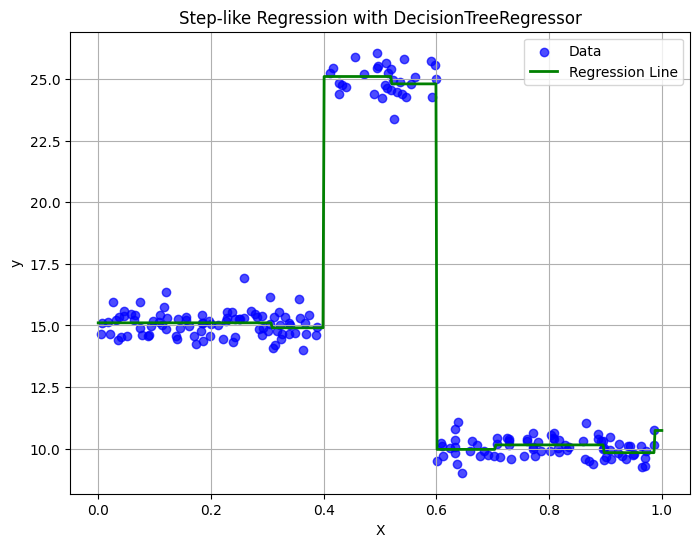

In [ ]:
regressor = DecisionTreeRegressor(max_depth=3)
regressor.fit(X, y)

X_test = np.linspace(0, 1, 500).reshape(-1, 1)
y_pred = regressor.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', alpha=0.7, label='Data')
plt.plot(X_test, y_pred, color='green', label='Regression Line', linewidth=2)
plt.title("Step-like Regression with DecisionTreeRegressor")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()